# Hierarchical Bayes
- parameters of one model layer are modeled by parameters in a higher layer
- The model can account for variability at different levels (e.g., between-school variability and within-school variability) and includes 
    - Data model (Likelihood): The first layer describes the observed data, based on a set of parameters $\theta$.  
    - First-level prior: The parameters $\theta$ from the data model are not fixed but are given a prior distribution that depends on other parameters called hyperparameters  $\Phi$. This allows for "borrowing strength" across groups. 
    - and a "hyperprior" distribution for the hyperparameters
    - Hyperprior: A prior distribution is assigned to the hyperparameters $\Phi$, which are the parameters governing the distribution of the first-level parameters. This higher level of the model captures the variability across the different groups. 


    HB adds layers of uncertainty on top of parameters — i.e., “priors on priors.”
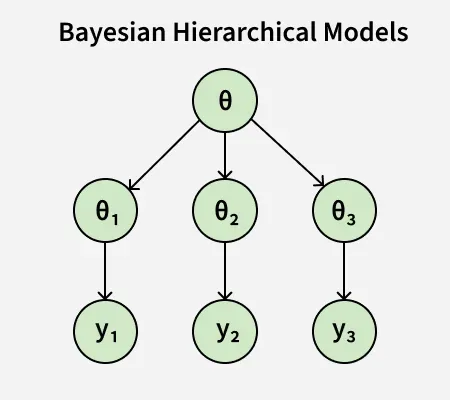

- Population level: μ_β, σ_β  ~  hyperpriors
- Group level (for each group i = 1...N):  β_i  ~  Normal(μ_β, σ_β)
- Observation level (for each observation j): y_ij  ~  Normal(β_i * x_ij, σ)

4. Real-World Intuition
```text
Imagine you’re estimating customer-level conversion rates:
Some customers have lots of data, others only a few clicks.
Hierarchical Bayes “shrinks” noisy small-sample estimates toward the population mean.
The amount of shrinkage depends on uncertainty (the posterior variance).
➡️ It’s like a smart, uncertainty-aware version of regularization + personalization in one model.
```

In [ ]:
import pymc as pm
#  Python API and fit them using Markov chain Monte Carlo (MCMC)(NUTS) methods.
# state-of-the-art inference algorithms, including MCMC (NUTS) and variational inference (ADVI)
import numpy as np
import pandas as pd

# Data
data = pd.DataFrame({
    "person": np.repeat(["A", "B", "C"], 2),
    "x": [1, 2, 1, 2, 1, 2],
    "y": [2, 3, 1, 2, 4, 6]
})

persons = data["person"].astype("category").cat.codes.values  # A=0, B=1, C=2
x = data["x"].values
y = data["y"].values
n_persons = len(np.unique(persons))

# Hierarchical model
with pm.Model() as hierarchical_model:
    # Hyperpriors for group (population) mean and SD
    mu_alpha = pm.Normal("mu_alpha", 0, 5)
    sigma_alpha = pm.HalfNormal("sigma_alpha", 2)
    mu_beta = pm.Normal("mu_beta", 0, 5)
    sigma_beta = pm.HalfNormal("sigma_beta", 2)

    # Group-level intercepts and slopes
    alpha = pm.Normal("alpha", mu=mu_alpha, sigma=sigma_alpha, shape=n_persons)
    beta = pm.Normal("beta", mu=mu_beta, sigma=sigma_beta, shape=n_persons)

    # Likelihood
    sigma = pm.HalfNormal("sigma", 1)
    mu = alpha[persons] + beta[persons] * x
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    trace = pm.sample(2000, tune=1000, target_accept=0.9)

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, mu_beta, sigma_beta, alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 125 seconds.
There were 615 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [2]:
import arviz as az
az.summary(trace, var_names=["mu_alpha", "mu_beta", "alpha", "beta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,0.996,1.104,-1.263,3.146,0.028,0.030,1477.0,1957.0,1.04
mu_beta,1.305,0.842,-0.313,3.019,0.027,0.023,866.0,1894.0,1.04
alpha[0],0.906,0.895,-1.022,2.445,0.027,0.035,942.0,1211.0,1.02
alpha[1],0.235,0.988,-1.614,2.108,0.041,0.034,606.0,941.0,1.03
alpha[2],1.869,0.973,-0.134,3.764,0.026,0.033,1413.0,1347.0,1.07
beta[0],1.078,0.584,0.008,2.252,0.020,0.023,731.0,1312.0,1.02
beta[1],0.903,0.627,-0.311,2.096,0.024,0.023,685.0,1035.0,1.04
beta[2],2.013,0.615,0.855,3.269,0.016,0.020,1601.0,1581.0,1.05


# Example: price-elasticityity of a product across multiple stores
- Data model: price elasticity of a product in a store is normally distributed with mean $\theta_i$
- First-level prior: $\theta_i \sim

In [28]:
import pandas as pd 
import numpy as np
import pymc as pm 
import arviz as az


In [ ]:
from statsmodels.datasets import grunfeld
data = grunfeld.load_pandas().data.copy()


In [3]:
data

,invest,value,capital,firm,year
0,317.600,3078.500,2.800,General Motors,1935.0
1,391.800,4661.700,52.600,General Motors,1936.0
2,410.600,5387.100,156.900,General Motors,1937.0
3,257.700,2792.200,209.200,General Motors,1938.0
4,330.800,4313.200,203.400,General Motors,1939.0
...,...,...,...,...,...
215,4.770,36.494,75.847,American Steel,1950.0
216,6.532,46.082,77.367,American Steel,1951.0
217,7.329,57.616,78.631,American Steel,1952.0
218,9.020,57.441,80.215,American Steel,1953.0


In [4]:
# Standardize continuous predictors to help sampling
for col in ["value", "capital"]:
    m, s = data[col].mean(), data[col].std()
    data[col + "_z"] = (data[col] - m) / s

In [12]:
# Group index for firms
firm_codes, firms = pd.factorize(data["firm"])
n_firms = len(firms)

n_firms, firms

(11,
 Index(['General Motors', 'US Steel', 'General Electric', 'Chrysler',
        'Atlantic Refining', 'IBM', 'Union Oil', 'Westinghouse', 'Goodyear',
        'Diamond Match', 'American Steel'],
       dtype='object'))

In [25]:
y = data["invest"].values


In [26]:
# 3) Hierarchical model in PyMC
with pm.Model() as model:
    # Hyperpriors for firm intercepts
    # mu_alpha: the population average intercept (baseline investment, after standardizing predictors).
    mu_alpha = pm.Normal("mu_alpha", 0.0, 1.0) # It should be within the pm.Model(): block 
    # sigma_alpha: the between-firm variability—how much firms differ in their baseline. Larger → more heterogeneity.
    sigma_alpha = pm.HalfNormal("sigma_alpha", 1.0)
    
    # Firm-specific intercepts (random intercept), WHICH will be shrunk toward mu_alpha (especially for firms with less data)
    alpha = pm.Normal("alpha", mu=mu_alpha, sigma=sigma_alpha, shape=n_firms)

    # Population (global) slopes for value and capital.
    beta_value = pm.Normal("beta_value", 0.0, 1.0)
    beta_cap   = pm.Normal("beta_cap", 0.0, 1.0)

    # Observation noise
    sigma = pm.HalfNormal("sigma", 5.0)

    # Linear predictor
    mu = alpha[firm_codes] + beta_value * data["value_z"].values + beta_cap * data["capital_z"].values

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    # 4) Sample
    idata = pm.sample(
        draws=1000, tune=1000, chains=4, target_accept=0.9, random_seed=42, progressbar=True
    )


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, alpha, beta_value, beta_cap, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 859 seconds.
There were 273 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [31]:
y_obs

y_obs

In [32]:
print(az.summary(idata, var_names=["mu_alpha", "sigma_alpha", "beta_value", "beta_cap", "sigma"], round_to=3))

# 6) Inspect shrinkage: compare some firm-specific intercepts alpha
alpha_summary = az.summary(idata, var_names=["alpha"], round_to=3)
print(alpha_summary.head(10))  # first few firms

# 7) Posterior predictive (for fit diagnostics)
with model:
    ppc = pm.sample_posterior_predictive(idata, var_names=["y_obs"], random_seed=42)

# Optional: model fit check
az.plot_ppc({"posterior_predictive": {"y_obs": ppc["y_obs"]}, "observed_data": {"y_obs": y}})

Sampling: [y_obs]


Output()

                mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_alpha       1.790  1.004    0.097    3.824      0.044    0.022   521.202   
sigma_alpha    2.581  1.718    0.296    5.660      0.149    0.049    81.588   
beta_value     2.546  1.039    0.433    4.394      0.033    0.028  1048.040   
beta_cap       1.928  0.953    0.242    3.750      0.042    0.020   511.615   
sigma        124.352  2.540  119.634  128.926      0.092    0.059   752.922   

             ess_tail  r_hat  
mu_alpha      455.504  1.013  
sigma_alpha    37.854  1.032  
beta_value   1065.744  1.004  
beta_cap     1128.576  1.008  
sigma         969.368  1.010  
           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha[0]  9.157  9.667  -0.507   28.888      0.579    0.430   167.390   
alpha[1]  6.820  7.052  -1.031   20.783      0.400    0.305   214.877   
alpha[2]  2.946  3.504  -2.696   10.530      0.130    0.150   720.909   
alpha[3]  2.827  3.454  -2.972   10.206      0.

KeyError: 'y_obs'